# 第14章：Split-K 并行 -- K维并行切分

## 前置知识
- 第09章：分块矩阵乘法基础
- 第12章：Block Pointer 与 Shared Memory
- 第13章：软件流水线

## 学习目标
- 理解标准 GEMM 在 **tall-skinny 矩阵** 上并行度不足的问题
- 掌握 **Split-K** 算法的原理
- 实现 Split-K GEMM kernel (在 Ch.13 pipeline kernel 基础上累进叠加)
- 了解 Split-K vs 标准 GEMM 的适用场景
- 与 **cuBLAS** 对比性能

## 累进优化
- ✅ Shared Memory / Block Pointer (Ch.12)
- ✅ 软件流水线 (Ch.13)
- ✅ **Split-K 并行 (本章新增)**

> **注意**: Split-K 是从 Ch.13 分出的一条**分支路径**, 适用于 tall-skinny 矩阵。
> Ch.15 的 Swizzle 是另一条分支路径, 适用于标准大方阵。
> Ch.18 的 ultimate kernel = smem + pipeline + swizzle (不含 Split-K)。

In [1]:
import torch
import triton
import triton.language as tl

## 14.1 标准 GEMM 的并行度问题

### 问题：tall-skinny 矩阵

```
Case 1: 方阵 (M=4096, N=4096, K=1024)
  BLOCK_M=128, BLOCK_N=128
  grid = (32, 32) = 1024 个 program
  → GPU (假设 80+ SMs) 可以完全利用 ✓

Case 2: tall-skinny (M=128, N=128, K=8192)
  grid = (1, 1) = 1 个 program!!
  → 只用了 1 个 SM, 其他 SM 空闲! ✗

Case 3: 中等宽矩阵 (M=256, N=256, K=16384)
  grid = (2, 2) = 4 个 program
  → 只用了 4 个 SM ✗
```

### Split-K 的解决方案

```
Split-K (SPLIT_K=8, M=128, N=128, K=8192):

K 维度被切成 8 份:
┌──────────┬──────────┬──────────┬──────────┬─...─┐
│ K chunk 0│ K chunk 1│ K chunk 2│ K chunk 3│     │
│ k=0:1024 │k=1024:2048│k=2048:3072│k=3072:4096│    │
└──────────┴──────────┴──────────┴──────────┴─...─┘
     ↓            ↓            ↓            ↓
  Program 0    Program 1    Program 2    Program 3  ...
     ↓            ↓            ↓            ↓
  C_partial_0  C_partial_1  C_partial_2  C_partial_3
     ↓            ↓            ↓            ↓
     └──────── atomic_add ────────────────┘
                     ↓
                C = Σ C_partial_i

并行度: 1 → 8 (提升 8x!)
```

### 工业界延伸: NVIDIA Stream-K

上面我们看到: 当 `grid = cdiv(M, BM) * cdiv(N, BN)` 太小时, 标准 tiled GEMM 会让大量 SM 空闲。

`Split-K` 的做法是:
- 不改变输出 tile 的数量
- 而是沿 `K` 维切出更多工作
- 让多个 program 分别计算 partial sum
- 最后用 `atomic_add` 合并

这能显著提升并行度, 但也带来两个代价:
1. 需要额外的 partial sum 合并
2. `atomic_add` / reduction 会引入额外开销

这就引出一个自然问题:

> 能不能不主要依赖 `K` 维切分, 而是通过更聪明的工作调度方式, 让 SM 持续有活干?

工业界一个代表性思路就是 **NVIDIA Stream-K**。

### Stream-K 的核心思想

`Stream-K` 更像是一种 **调度策略 (scheduling strategy)**, 而不只是一个新的 GEMM 数学公式。

直观地说, 它不是先把输出矩阵静态切成固定 tile, 再问 "要不要把 K 也切开?";
而是反过来问:

> 如何把整个 GEMM 的工作流式地分发给各个 SM, 让它们尽量少出现尾波 (tail effect) 和空转?

核心区别:

- **Split-K**: 通过切 `K` 增加 reduction 并行度
- **Stream-K**: 通过流式分配 work tile / work chunk 增强负载均衡
- **目标相似**: 都想提高 SM 利用率
- **机制不同**: 一个偏 reduction 切分, 一个偏 persistent work scheduling

所以可以把 `Stream-K` 粗略理解为:

```text
不是把 "一个 tile 的 K 维工作" 切给更多 program,
而是把 "整个 GEMM 的 tile 工作流" 更灵活地流过各个 SM。
```

### Stream-K 的简化伪码

下面的伪码只展示 **调度思路**, 不代表 production kernel 的完整细节:

```python
# 全局有一条线性的 work stream
# 每个 work item 可以理解为: 某个 tile, 或某个 tile 的一段 K 工作
work_cursor = 0

while True:
    my_work = atomic_fetch_add(work_cursor, CHUNK_SIZE)
    if my_work >= total_work:
        break

    # 解析这段工作属于哪个 tile / 哪段 K 范围
    tile_id, k_begin, k_end = decode(my_work)

    # 计算当前 chunk
    partial = gemm_partial(tile_id, k_begin, k_end)

    # 写回/合并结果
    accumulate(tile_id, partial)
```

关键观察:
- 每个 SM 不是一次只绑定一个静态 tile, 而是不断领取下一段工作
- 当某些 tile 提前结束时, 空出来的 SM 可以继续处理后续 work
- 这样能减少尾波, 改善负载不均

> 真实的 `Stream-K` kernel 还需要处理同步、partial sum 边界、tile 所有权、epilogue 合并、以及架构相关细节。
> 这里的目标只是理解它的 **scheduling intuition**, 不是复刻 NVIDIA 的 production 实现。

### Standard vs Split-K vs Stream-K

| 方法 | 额外并行度来源 | 主要代价 | 更适合的场景 | 教学/实现复杂度 |
|------|----------------|----------|--------------|-----------------|
| Standard tiled GEMM | 仅来自 `M × N` 输出 tile | tile 数太少时 SM 吃不满 | 常规大矩阵 | 低 |
| Split-K | 额外把 `K` 切成多份 | partial sum 合并, `atomic_add` 开销 | `M,N` 小但 `K` 大 | 中 |
| Stream-K | 更灵活的 tile / work chunk 流式调度 | 调度、同步、所有权管理更复杂 | tile 数不足、负载不均、尾波明显的场景 | 高 |

因此, 本章的 hands-on 主线仍然选择 `Split-K`:
- 它最直接展示 `K` 维并行
- 也最适合在 Triton 中讲清 `partial sum + atomic accumulation`

下面我们继续实现 **Split-K Pipeline GEMM**。

## 14.2 实现: Split-K Pipeline GEMM

在 Ch.13 的 pipeline kernel 基础上累进叠加:
- grid 从 2D `(M_blocks, N_blocks)` 改为 2D `(M_blocks * N_blocks, SPLIT_K)`
- K 循环只处理 `[k_start, k_end)` 范围
- 写回使用 `tl.atomic_add` 合并部分和
- 保留 `num_stages` 控制流水线深度

In [2]:
@triton.jit
def matmul_splitk_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
    SPLIT_K: tl.constexpr,
):
    """
    Split-K Pipeline GEMM kernel.

    累进优化:
      ✅ make_block_ptr (Ch.12) — 结构化内存访问
      ✅ FP32 累加器 — 数值精度
      ✅ Tensor Core (tl.dot) — 自动映射
      ✅ num_stages (Ch.13) — 流水线 (通过 launch 参数)
      ✅ Split-K (本章) — K 维并行

    grid = (cdiv(M, BM) * cdiv(N, BN), SPLIT_K)
    """
    # ========== pid 解码 ==========
    pid_mn = tl.program_id(0)  # M-N 维度
    pid_k = tl.program_id(1)   # K 维度 split

    grid_n = tl.cdiv(N, BLOCK_N)
    pid_m = pid_mn // grid_n
    pid_n = pid_mn % grid_n

    # ========== 计算当前 split 的 K block 范围 ==========
    # 关键点: split 边界必须和 BLOCK_K 对齐, 否则最后一个 tile 会越过自己的 split。
    total_k_blocks = tl.cdiv(K, BLOCK_K)
    blocks_per_split = tl.cdiv(total_k_blocks, SPLIT_K)
    block_start = pid_k * blocks_per_split
    block_end = min(block_start + blocks_per_split, total_k_blocks)
    k_start = block_start * BLOCK_K

    # ========== Block Pointer (Ch.12) ==========
    a_block_ptr = tl.make_block_ptr(
        base=a_ptr, shape=(M, K), strides=(stride_am, stride_ak),
        offsets=(pid_m * BLOCK_M, k_start),
        block_shape=(BLOCK_M, BLOCK_K), order=(1, 0),
    )
    b_block_ptr = tl.make_block_ptr(
        base=b_ptr, shape=(K, N), strides=(stride_bk, stride_bn),
        offsets=(k_start, pid_n * BLOCK_N),
        block_shape=(BLOCK_K, BLOCK_N), order=(1, 0),
    )

    # ========== FP32 累加器 ==========
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)

    # ========== K 循环 (只处理分配的 block 范围) + Pipeline (num_stages) ==========
    for _ in range(block_start, block_end):
        a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
        b_tile = tl.load(b_block_ptr, boundary_check=(0, 1))
        acc = tl.dot(a_tile, b_tile, acc=acc)
        a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
        b_block_ptr = tl.advance(b_block_ptr, (BLOCK_K, 0))

    # ========== 使用 atomic_add 写回部分和 ==========
    c = acc.to(tl.float16)
    rm = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    rn = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    c_ptrs = c_ptr + rm[:, None] * stride_cm + rn[None, :] * stride_cn
    c_mask = (rm[:, None] < M) & (rn[None, :] < N)
    tl.atomic_add(c_ptrs, c, mask=c_mask)

In [3]:
def matmul_splitk(a, b, BLOCK_M=128, BLOCK_N=128, BLOCK_K=32,
                   SPLIT_K=4, num_stages=3):
    """Split-K Pipeline GEMM。C 必须初始化为 0 (atomic_add 累加)。"""
    M, K = a.shape
    K2, N = b.shape
    assert K == K2
    c = torch.zeros((M, N), device=a.device, dtype=a.dtype)  # 必须为 0!
    grid = (triton.cdiv(M, BLOCK_M) * triton.cdiv(N, BLOCK_N), SPLIT_K)
    matmul_splitk_kernel[grid](
        a, b, c, M, N, K,
        a.stride(0), a.stride(1), b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
        SPLIT_K=SPLIT_K, num_stages=num_stages,
    )
    return c

# Ch.13 的标准 pipeline kernel (用于对比)
@triton.jit
def matmul_standard_kernel(
    a_ptr, b_ptr, c_ptr,
    M, N, K,
    stride_am, stride_ak, stride_bk, stride_bn, stride_cm, stride_cn,
    BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr, BLOCK_K: tl.constexpr,
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)
    a_block_ptr = tl.make_block_ptr(
        base=a_ptr, shape=(M, K), strides=(stride_am, stride_ak),
        offsets=(pid_m * BLOCK_M, 0), block_shape=(BLOCK_M, BLOCK_K), order=(1, 0),
    )
    b_block_ptr = tl.make_block_ptr(
        base=b_ptr, shape=(K, N), strides=(stride_bk, stride_bn),
        offsets=(0, pid_n * BLOCK_N), block_shape=(BLOCK_K, BLOCK_N), order=(1, 0),
    )
    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)
    for k in range(0, K, BLOCK_K):
        a_tile = tl.load(a_block_ptr, boundary_check=(0, 1))
        b_tile = tl.load(b_block_ptr, boundary_check=(0, 1))
        acc = tl.dot(a_tile, b_tile, acc=acc)
        a_block_ptr = tl.advance(a_block_ptr, (0, BLOCK_K))
        b_block_ptr = tl.advance(b_block_ptr, (BLOCK_K, 0))
    c_block_ptr = tl.make_block_ptr(
        base=c_ptr, shape=(M, N), strides=(stride_cm, stride_cn),
        offsets=(pid_m * BLOCK_M, pid_n * BLOCK_N),
        block_shape=(BLOCK_M, BLOCK_N), order=(1, 0),
    )
    tl.store(c_block_ptr, acc.to(tl.float16), boundary_check=(0, 1))

def matmul_standard(a, b, BLOCK_M=128, BLOCK_N=128, BLOCK_K=32, num_stages=3):
    M, K = a.shape
    K2, N = b.shape
    assert K == K2
    c = torch.empty((M, N), device=a.device, dtype=a.dtype)
    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))
    matmul_standard_kernel[grid](
        a, b, c, M, N, K,
        a.stride(0), a.stride(1), b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
        BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N, BLOCK_K=BLOCK_K,
        num_stages=num_stages,
    )
    return c

In [4]:
# ========== 正确性验证 ==========
torch.manual_seed(42)

print("Split-K 正确性验证 (包含非整齐 split 边界):")
for M, N, K, SPLIT_K in [
    (128, 128, 2048, 4),
    (256, 256, 4096, 8),
    (512, 512, 8192, 4),
    (2048, 2048, 1024, 2),
    (256, 256, 2304, 7),
    (384, 192, 2816, 6),
]:
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)
    c_splitk = matmul_splitk(a, b, SPLIT_K=SPLIT_K)
    c_ref = torch.matmul(a, b)
    max_err = (c_splitk - c_ref).abs().max().item()
    rel_err = torch.norm(c_splitk.float() - c_ref.float()) / torch.norm(c_ref.float())
    print(f"  ({M:>4}x{K:>5}) @ ({K:>5}x{N:>4}), SPLIT_K={SPLIT_K}: "
          f"max_err={max_err:.4f}, rel_err={rel_err:.6f}")
    assert max_err <= 0.5, f"Split-K correctness regression for K={K}, SPLIT_K={SPLIT_K}: {max_err}"

Split-K 正确性验证 (包含非整齐 split 边界):


  ( 128x 2048) @ ( 2048x 128), SPLIT_K=4: max_err=0.1250, rel_err=0.000487
  ( 256x 4096) @ ( 4096x 256), SPLIT_K=8: max_err=0.2500, rel_err=0.000542
  ( 512x 8192) @ ( 8192x 512), SPLIT_K=4: max_err=0.2500, rel_err=0.000487
  (2048x 1024) @ ( 1024x2048), SPLIT_K=2: max_err=0.1250, rel_err=0.000358
  ( 256x 2304) @ ( 2304x 256), SPLIT_K=7: max_err=0.2500, rel_err=0.000555
  ( 384x 2816) @ ( 2816x 192), SPLIT_K=6: max_err=0.2500, rel_err=0.000496


## 14.3 性能对比: Standard vs Split-K vs cuBLAS

Split-K 在 tall-skinny 矩阵上应该显著优于标准 GEMM, 但在大方阵上因 atomic_add 开销可能更慢。

In [5]:
# ========== benchmark 工具 ==========
def benchmark_fn(fn, a, b, num_warmup=25, num_rep=100, **kwargs):
    for _ in range(num_warmup):
        fn(a, b, **kwargs)
    torch.cuda.synchronize()
    s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    s.record()
    for _ in range(num_rep):
        fn(a, b, **kwargs)
    e.record()
    torch.cuda.synchronize()
    return s.elapsed_time(e) / num_rep

def benchmark_cublas(a, b, num_warmup=25, num_rep=100):
    for _ in range(num_warmup):
        torch.matmul(a, b)
    torch.cuda.synchronize()
    s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    s.record()
    for _ in range(num_rep):
        torch.matmul(a, b)
    e.record()
    torch.cuda.synchronize()
    return s.elapsed_time(e) / num_rep

In [6]:
# ========== Standard vs Split-K vs cuBLAS ==========
BM, BN, BK = 128, 128, 32
gpu_name = torch.cuda.get_device_name(0)
num_sms = torch.cuda.get_device_properties(0).multi_processor_count
print(f"GPU: {gpu_name}, SMs: {num_sms}")

print(f"\n{'Shape':>25} | {'#Progs':>7} {'Standard':>10} | {'SK':>3} {'#Progs':>7} {'Split-K':>10} | {'cuBLAS':>10} | {'SK加速':>7} {'SK/cuBLAS':>10}")
print("-" * 115)

test_cases = [
    (128,  128,  8192,  8),
    (256,  256,  8192,  8),
    (256,  256,  4096,  4),
    (512,  512,  4096,  4),
    (1024, 1024, 4096,  4),
    (2048, 2048, 1024,  2),
    (4096, 4096, 1024,  2),
]

for M, N, K, SPLIT_K in test_cases:
    a = torch.randn(M, K, device='cuda', dtype=torch.float16)
    b = torch.randn(K, N, device='cuda', dtype=torch.float16)

    progs_std = triton.cdiv(M, BM) * triton.cdiv(N, BN)
    progs_sk = progs_std * SPLIT_K

    ms_std = benchmark_fn(matmul_standard, a, b, num_stages=3)
    ms_sk = benchmark_fn(matmul_splitk, a, b, SPLIT_K=SPLIT_K, num_stages=3)
    ms_cu = benchmark_cublas(a, b)

    speedup = ms_std / ms_sk
    vs_cu = ms_cu / ms_sk
    shape_str = f"({M}x{K})@({K}x{N})"
    print(f"{shape_str:>25} | {progs_std:>7} {ms_std:>9.3f}ms | {SPLIT_K:>3} {progs_sk:>7} {ms_sk:>9.3f}ms | {ms_cu:>9.3f}ms | {speedup:>6.2f}x {vs_cu:>9.2f}x")

GPU: NVIDIA RTX PRO 6000 Blackwell Workstation Edition, SMs: 188

                    Shape |  #Progs   Standard |  SK  #Progs    Split-K |     cuBLAS |    SK加速  SK/cuBLAS
-------------------------------------------------------------------------------------------------------------------
    (128x8192)@(8192x128) |       1     0.126ms |   8       8     0.034ms |     0.016ms |   3.73x      0.47x
    (256x8192)@(8192x256) |       4     0.130ms |   8      32     0.030ms |     0.018ms |   4.26x      0.59x
    (256x4096)@(4096x256) |       4     0.064ms |   4      16     0.033ms |     0.015ms |   1.96x      0.46x
    (512x4096)@(4096x512) |      16     0.068ms |   4      64     0.037ms |     0.016ms |   1.84x      0.43x
  (1024x4096)@(4096x1024) |      64     0.064ms |   4     256     0.042ms |     0.032ms |   1.51x      0.75x
  (2048x1024)@(1024x2048) |     256     0.036ms |   2     512     0.041ms |     0.035ms |   0.86x      0.85x
  (4096x1024)@(1024x4096) |    1024     0.102ms |   2    2

## 14.x 统一 Shape Set 数值表

为了让 Part 3 的所有优化章节可以横向比较，本表使用与 Ch.12、Ch.13 和 Ch.18 相同的 7 个共享矩阵形状。

这些 shape 的目标是保证**跨章节可比性**，不专门挑选 Split-K 的最佳场景；因此它更像一张统一协议表，而不是“Split-K 最擅长 workload”排行榜。本章后面的 `SPLIT_K` 调优实验，仍然负责展示 Split-K 真正受益的 regime。

本章比较 `Ch.14 split-k`、`Ch.13 pipeline` 与 `cuBLAS`，主指标是 `latency_ms`，并附带 `TFLOPS`、相对 `cuBLAS` 的速度比，以及相对前一章 `Ch.13 pipeline` 的速度比。

为避免固定 `SPLIT_K=4` 带来的任意性，这里会根据每个 shape 的输出 tile 并行度，自动选择一个保守的 `SPLIT_K`。

In [7]:
import sys
from pathlib import Path

for candidate in (Path.cwd(), Path.cwd() / "03_matmul_optimization"):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.append(candidate_str)

from benchmark_utils import (
    BENCHMARK_SHAPES,
    add_relative_columns,
    benchmark_method,
    format_results,
    make_fp16_inputs,
)
from scripts.simt_naive_ext import simt_naive


def choose_split_k(shape, block_m=128, block_n=128, max_split_k=16):
    standard_programs = triton.cdiv(shape.M, block_m) * triton.cdiv(shape.N, block_n)
    target_programs = torch.cuda.get_device_properties(0).multi_processor_count * 2
    if standard_programs >= target_programs:
        return 2

    desired_split_k = max(2, (target_programs + standard_programs - 1) // standard_programs)
    split_k = 1
    while split_k < desired_split_k:
        split_k *= 2
    return min(max_split_k, split_k)


print("Ch.14 shared-shape benchmark: split-k vs pipeline vs cuBLAS")
chapter14_results = []
previous_map = {"Ch.14 split-k": "Ch.13 pipeline"}
split_k_by_shape = {}

for shape in BENCHMARK_SHAPES:
    a, b = make_fp16_inputs(shape.M, shape.N, shape.K)
    c_ref = torch.matmul(a, b)
    split_k = choose_split_k(shape)
    split_k_by_shape[shape.name] = split_k
    methods = {
        "SIMT Naive": simt_naive,
        "Ch.12 smem": lambda x, y: matmul_standard(x, y, num_stages=1),
        "Ch.13 pipeline": lambda x, y: matmul_standard(x, y, num_stages=3),
        "Ch.14 split-k": lambda x, y, split_k=split_k: matmul_splitk(x, y, SPLIT_K=split_k, num_stages=3),
        "cuBLAS": lambda x, y: torch.matmul(x, y),
    }
    for method_name, fn in methods.items():
        chapter14_results.append(
            benchmark_method(
                method_name,
                fn,
                shape,
                a,
                b,
                c_ref=c_ref,
                warmup=25,
                rep=100,
                atol={
                    "SIMT Naive": max(3.0, shape.K * 0.003),
                    "Ch.14 split-k": 1.5,
                }.get(method_name, 0.5),
            )
        )
    del a, b, c_ref
    torch.cuda.empty_cache()

chapter14_df = add_relative_columns(
    format_results(chapter14_results),
    previous_method_by_method=previous_map,
)
print("Per-shape SPLIT_K heuristic:", split_k_by_shape)
chapter14_df[[
    "shape_name",
    "category",
    "method",
    "latency_ms",
    "tflops",
    "speedup_vs_cublas",
    "speedup_vs_previous",
    "max_err",
    "passed",
]]

Ch.14 shared-shape benchmark: split-k vs pipeline vs cuBLAS


Per-shape SPLIT_K heuristic: {'square-2k': 2, 'square-4k': 2, 'tall-8k-x-512': 2, 'tall-16k-x-256': 2, 'wide-512-x-8k': 2, 'largeK-2k-x-8k': 2, 'largeK-1k-x-16k': 8}


,shape_name,category,method,latency_ms,tflops,speedup_vs_cublas,speedup_vs_previous,max_err,passed
0,square-2k,square,SIMT Naive,2.737766,6.275141,0.022460,NaN,4.6250,True
1,square-2k,square,Ch.12 smem,0.071516,240.223594,0.859800,NaN,0.0000,True
2,square-2k,square,Ch.13 pipeline,0.063839,269.110927,0.963193,NaN,0.0000,True
3,square-2k,square,Ch.14 split-k,0.065318,263.017306,0.941383,0.977356,0.1250,True
4,square-2k,square,cuBLAS,0.061490,279.394708,1.000000,NaN,0.0000,True
5,square-4k,square,SIMT Naive,22.218071,6.185908,0.021233,NaN,8.2500,True
6,square-4k,square,Ch.12 smem,0.431736,318.340272,1.092676,NaN,0.0000,True
7,square-4k,square,Ch.13 pipeline,0.409227,335.850262,1.152777,NaN,0.0000,True
8,square-4k,square,Ch.14 split-k,0.426998,321.872776,1.104801,0.958382,0.2500,True
9,square-4k,square,cuBLAS,0.471748,291.340070,1.000000,NaN,0.0000,True


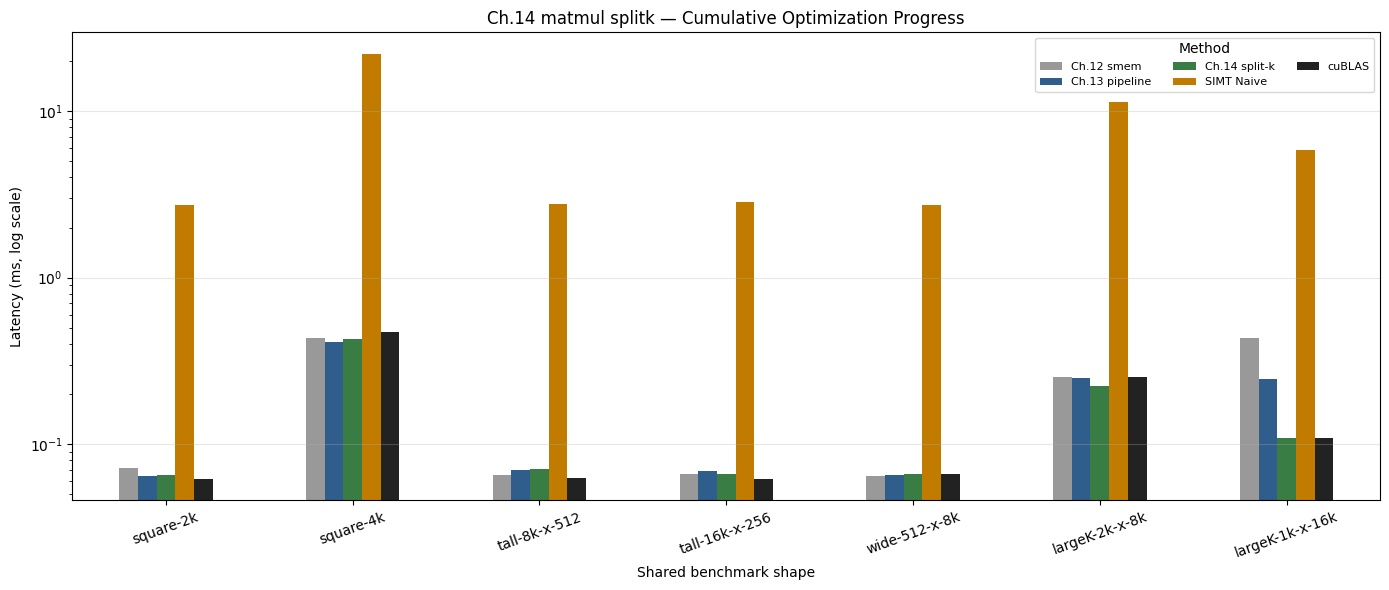

method,Ch.12 smem,Ch.13 pipeline,Ch.14 split-k,SIMT Naive,cuBLAS
shape_name,,,,,
square-2k,0.071516,0.063839,0.065318,2.737766,0.061490
square-4k,0.431736,0.409227,0.426998,22.218071,0.471748
tall-8k-x-512,0.065221,0.069480,0.070946,2.766970,0.062042
tall-16k-x-256,0.065617,0.069258,0.065967,2.835865,0.062027
wide-512-x-8k,0.063923,0.064683,0.066155,2.746850,0.066183
largeK-2k-x-8k,0.251671,0.250009,0.223830,11.347366,0.254453
largeK-1k-x-16k,0.436553,0.246927,0.108068,5.861178,0.108395


In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'sans-serif']

plot_methods = ["SIMT Naive", "Ch.12 smem", "Ch.13 pipeline", "Ch.14 split-k", "cuBLAS"]
plot_df = chapter14_df[chapter14_df["method"].isin(plot_methods)].copy()
shape_order = [shape.name for shape in BENCHMARK_SHAPES]
pivot_df = plot_df.pivot(index="shape_name", columns="method", values="latency_ms").reindex(shape_order)

ax = pivot_df.plot(
    kind="bar",
    figsize=(14, 6),
    rot=20,
    logy=True,
    color=["#999999", "#2F5D8C", "#3A7D44", "#C17C00", "#222222"],
)
ax.set_xlabel("Shared benchmark shape")
ax.set_ylabel("Latency (ms, log scale)")
ax.set_title("Ch.14 matmul splitk — Cumulative Optimization Progress")
ax.legend(title="Method", ncol=3, fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

pivot_df


## 14.4 SPLIT_K 参数调优

对于给定的矩阵形状, 最优的 SPLIT_K 取决于标准并行度与 SM 数量的关系:

```
决策规则:
  standard_programs = cdiv(M, BM) * cdiv(N, BN)
  if standard_programs < num_SMs * 2:
    → GPU 利用率不足, 使用 Split-K
    → SPLIT_K ≈ ceil(num_SMs * 2 / standard_programs)
  else:
    → 标准 GEMM 已有足够并行度, atomic_add 开销不值得
```

In [9]:
# ========== 不同 SPLIT_K 值的效果 ==========
M, N, K = 256, 256, 8192
a = torch.randn(M, K, device='cuda', dtype=torch.float16)
b = torch.randn(K, N, device='cuda', dtype=torch.float16)

print(f"矩阵: ({M}x{K}) @ ({K}x{N})")
print(f"标准 programs: {triton.cdiv(M,128) * triton.cdiv(N,128)}")
print(f"GPU SMs: {num_sms}")
flops = 2.0 * M * N * K

ms_cu = benchmark_cublas(a, b)
tf_cu = flops / (ms_cu * 1e-3) / 1e12
print(f"cuBLAS: {ms_cu:.3f}ms, {tf_cu:.1f} TFLOPS")

print(f"\n{'Method':>10} | {'Programs':>10} | {'时间(ms)':>10} | {'TFLOPS':>8} | {'vs cuBLAS':>10}")
print("-" * 60)

# Standard
ms_std = benchmark_fn(matmul_standard, a, b, num_stages=3)
tf_std = flops / (ms_std * 1e-3) / 1e12
print(f"{'标准':>10} | {triton.cdiv(M,128)*triton.cdiv(N,128):>10} | {ms_std:>10.3f} | {tf_std:>8.1f} | {ms_cu/ms_std:>9.2f}x")

# Split-K sweep
for sk in [2, 4, 8, 16, 32]:
    progs = triton.cdiv(M, 128) * triton.cdiv(N, 128) * sk
    ms = benchmark_fn(matmul_splitk, a, b, SPLIT_K=sk, num_stages=3)
    tf = flops / (ms * 1e-3) / 1e12
    print(f"{'SK='+str(sk):>10} | {progs:>10} | {ms:>10.3f} | {tf:>8.1f} | {ms_cu/ms:>9.2f}x")

矩阵: (256x8192) @ (8192x256)
标准 programs: 4
GPU SMs: 188
cuBLAS: 0.017ms, 63.1 TFLOPS

    Method |   Programs |     时间(ms) |   TFLOPS |  vs cuBLAS
------------------------------------------------------------
        标准 |          4 |      0.123 |      8.7 |      0.14x
      SK=2 |          8 |      0.072 |     14.9 |      0.24x
      SK=4 |         16 |      0.042 |     25.7 |      0.41x
      SK=8 |         32 |      0.032 |     33.1 |      0.52x
     SK=16 |         64 |      0.034 |     31.3 |      0.50x
     SK=32 |        128 |      0.031 |     34.7 |      0.55x


## 14.5 总结

### 本章要点

1. **并行度不足问题**: 当 M,N 较小时, 标准 GEMM 的 grid 太小, 无法充分利用 GPU

2. **Split-K 算法**:
   - 将 K 维度切成 SPLIT_K 份
   - 每份由不同的 program 计算部分和
   - 使用 `tl.atomic_add` 合并结果
   - 并行度从 `cdiv(M,BM)*cdiv(N,BN)` 提升到 `cdiv(M,BM)*cdiv(N,BN)*SPLIT_K`

3. **累进叠加**: 在 Ch.13 的 pipeline kernel 基础上添加 Split-K, 同时保留 `num_stages`

4. **适用场景**:
   - ✅ M,N 小但 K 大的 tall-skinny 矩阵
   - ✗ 大方阵 (标准 GEMM 已有足够并行度, atomic_add 反而拖慢)

5. **决策规则**: `standard_programs < num_SMs * 2` 时考虑 Split-K

### 累进优化状态
| 特性 | 状态 | 路径 |
|------|------|------|
| Shared Memory / Block Pointer | ✅ Ch.12 | 主线 |
| 软件流水线 (num_stages) | ✅ Ch.13 | 主线 |
| **Split-K 并行** | **✅ 本章** | **分支** (tall-skinny) |
| L2 Cache Swizzle | → Ch.15 | 分支 (标准矩阵) |

### 下一章预告

第15章将介绍 **L2 Cache Swizzle**, 通过重排 block 调度顺序来优化 L2 缓存命中率。
Swizzle 是从 Ch.13 分出的另一条分支路径, 适用于标准大方阵, 将在 Ch.18 ultimate 中使用。